# CT052-3-M-NLP — System 2: Sentiment Analysis
## IMDB Movie Reviews — Text Classification
---
**Dataset:** IMDB Dataset of 50K Movie Reviews  
**Task:** Binary Sentiment Classification (Positive / Negative)  
**Models:** Logistic Regression | Multinomial Naive Bayes | Linear SVM  


## 1. Import Libraries

In [1]:
# ── Core ──────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud

# ── NLP ───────────────────────────────────────────────────────────────────────
import nltk
nltk.download('stopwords',   quiet=True)
nltk.download('punkt',       quiet=True)
nltk.download('punkt_tab',   quiet=True)
from nltk.corpus import stopwords
from nltk.stem  import PorterStemmer

# ── ML ────────────────────────────────────────────────────────────────────────
from sklearn.model_selection  import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model     import LogisticRegression
from sklearn.naive_bayes      import MultinomialNB
from sklearn.svm              import LinearSVC
from sklearn.pipeline         import Pipeline
from sklearn.metrics          import (accuracy_score, classification_report,
                                      confusion_matrix, roc_auc_score, roc_curve)
from sklearn.preprocessing    import LabelEncoder

# ── Persistence ───────────────────────────────────────────────────────────────
import pickle, os

print('All libraries loaded successfully ✔')

All libraries loaded successfully ✔


---
## 2. Dataset and Exploratory Data Analysis (EDA)
### 2.1 Load Dataset

In [2]:
# Load the IMDB dataset
df = pd.read_csv('IMDB Dataset.csv')

print('Shape:', df.shape)
print('Columns:', list(df.columns))
df.head()

Shape: (50000, 2)
Columns: ['review', 'sentiment']


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### 2.2 Basic Dataset Information

In [3]:
print('='*55)
print('DATASET OVERVIEW')
print('='*55)
print(f'Total Reviews      : {len(df):,}')
print(f'Columns            : {list(df.columns)}')
print(f'Missing Values     : {df.isnull().sum().sum()}')
print(f'Duplicate Rows     : {df.duplicated().sum()}')
print()
print('Sentiment Distribution:')
print(df['sentiment'].value_counts())
print()
print('Data Types:')
print(df.dtypes)

DATASET OVERVIEW
Total Reviews      : 50,000
Columns            : ['review', 'sentiment']
Missing Values     : 0
Duplicate Rows     : 418

Sentiment Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Data Types:
review       object
sentiment    object
dtype: object


### 2.3 Class Distribution

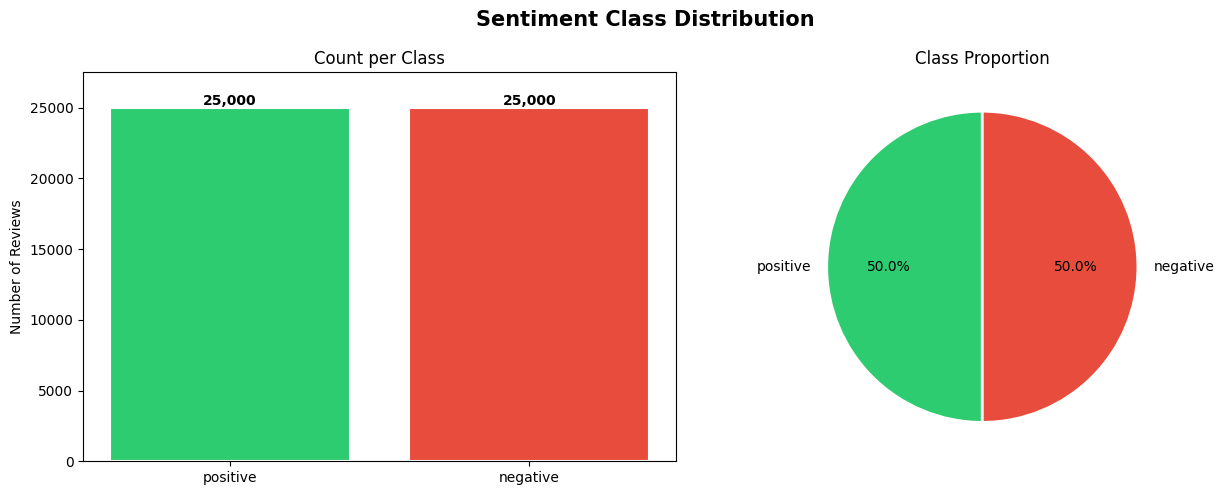

Dataset is perfectly balanced — 50% positive, 50% negative ✔


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Sentiment Class Distribution', fontsize=15, fontweight='bold')

# Bar chart
counts  = df['sentiment'].value_counts()
colours = ['#2ECC71', '#E74C3C']
bars = axes[0].bar(counts.index, counts.values, color=colours, edgecolor='white', linewidth=1.5)
axes[0].set_title('Count per Class')
axes[0].set_ylabel('Number of Reviews')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', fontweight='bold')
axes[0].set_ylim(0, counts.max() + 2500)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colours, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.savefig('plot_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dataset is perfectly balanced — 50% positive, 50% negative ✔')

### 2.4 Review Length Analysis

In [5]:
# Add review length features
df['review_length']  = df['review'].apply(len)
df['word_count']     = df['review'].apply(lambda x: len(x.split()))

print('Review Length Statistics:')
print(df.groupby('sentiment')[['review_length','word_count']].describe().round(1))

Review Length Statistics:
          review_length                                                       \
                  count    mean     std   min    25%    50%     75%      max   
sentiment                                                                      
negative        25000.0  1294.1   945.9  32.0  706.0  973.0  1567.2   8969.0   
positive        25000.0  1324.8  1031.5  65.0  691.0  968.0  1614.0  13704.0   

          word_count                                                   
               count   mean    std   min    25%    50%    75%     max  
sentiment                                                              
negative     25000.0  229.5  164.9   4.0  128.0  174.0  278.0  1522.0  
positive     25000.0  232.8  177.5  10.0  125.0  172.0  284.0  2470.0  


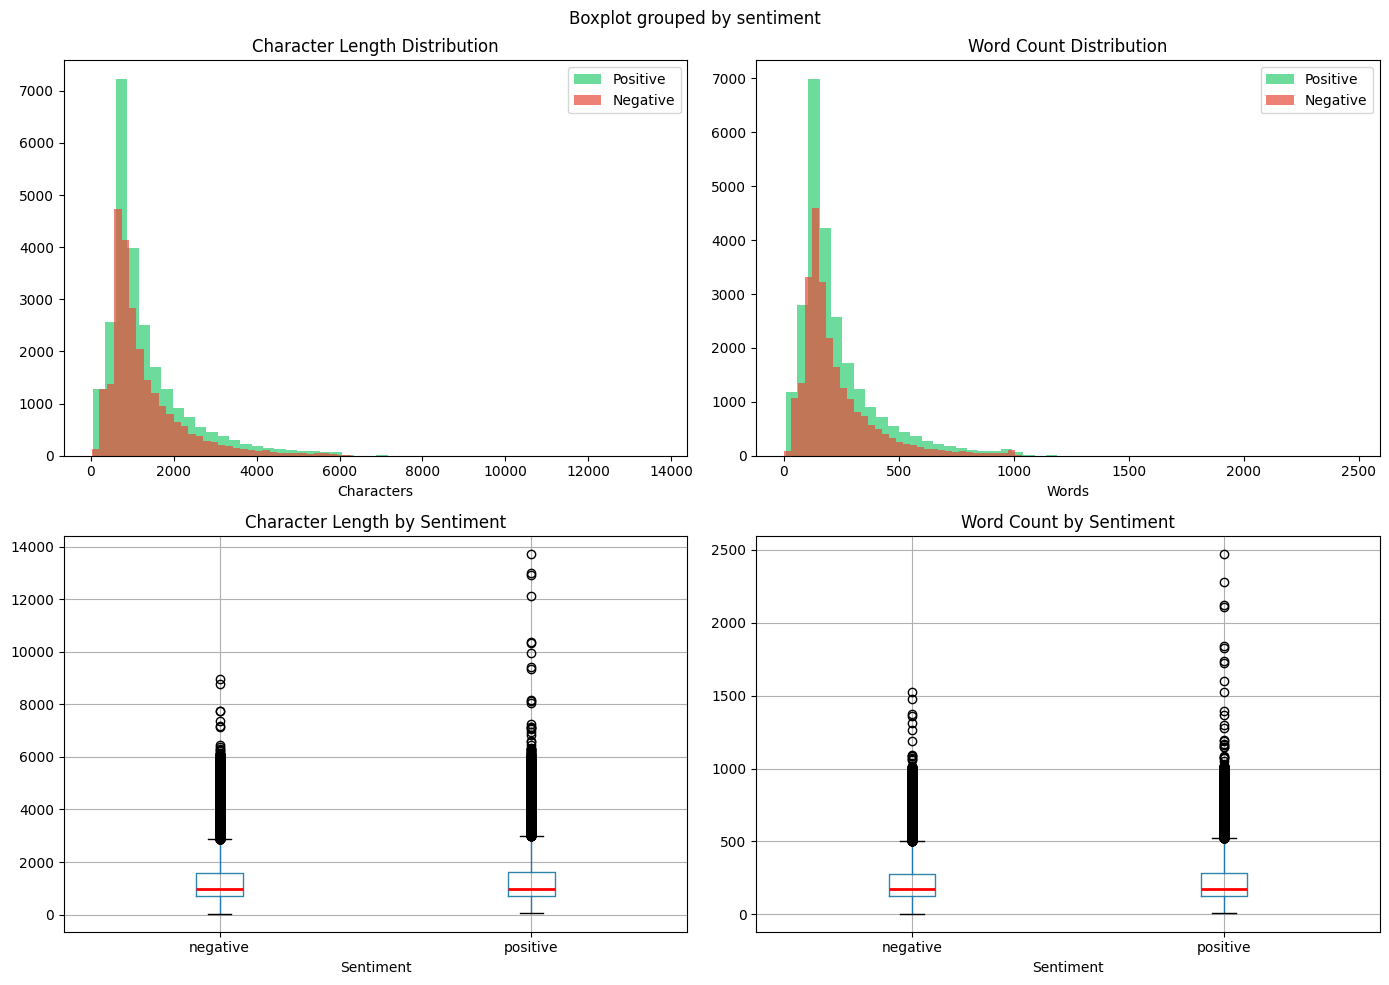

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Review Length Analysis', fontsize=14, fontweight='bold')

pos = df[df['sentiment']=='positive']
neg = df[df['sentiment']=='negative']

# Character length distribution
axes[0,0].hist(pos['review_length'], bins=50, alpha=0.7, color='#2ECC71', label='Positive')
axes[0,0].hist(neg['review_length'], bins=50, alpha=0.7, color='#E74C3C', label='Negative')
axes[0,0].set_title('Character Length Distribution')
axes[0,0].set_xlabel('Characters')
axes[0,0].legend()

# Word count distribution
axes[0,1].hist(pos['word_count'], bins=50, alpha=0.7, color='#2ECC71', label='Positive')
axes[0,1].hist(neg['word_count'], bins=50, alpha=0.7, color='#E74C3C', label='Negative')
axes[0,1].set_title('Word Count Distribution')
axes[0,1].set_xlabel('Words')
axes[0,1].legend()

# Boxplot - character length
df.boxplot(column='review_length', by='sentiment', ax=axes[1,0],
           boxprops=dict(color='#2E86AB'),
           medianprops=dict(color='red', linewidth=2))
axes[1,0].set_title('Character Length by Sentiment')
axes[1,0].set_xlabel('Sentiment')

# Boxplot - word count
df.boxplot(column='word_count', by='sentiment', ax=axes[1,1],
           boxprops=dict(color='#2E86AB'),
           medianprops=dict(color='red', linewidth=2))
axes[1,1].set_title('Word Count by Sentiment')
axes[1,1].set_xlabel('Sentiment')

plt.tight_layout()
plt.savefig('plot_review_length.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.5 Word Cloud Visualisation

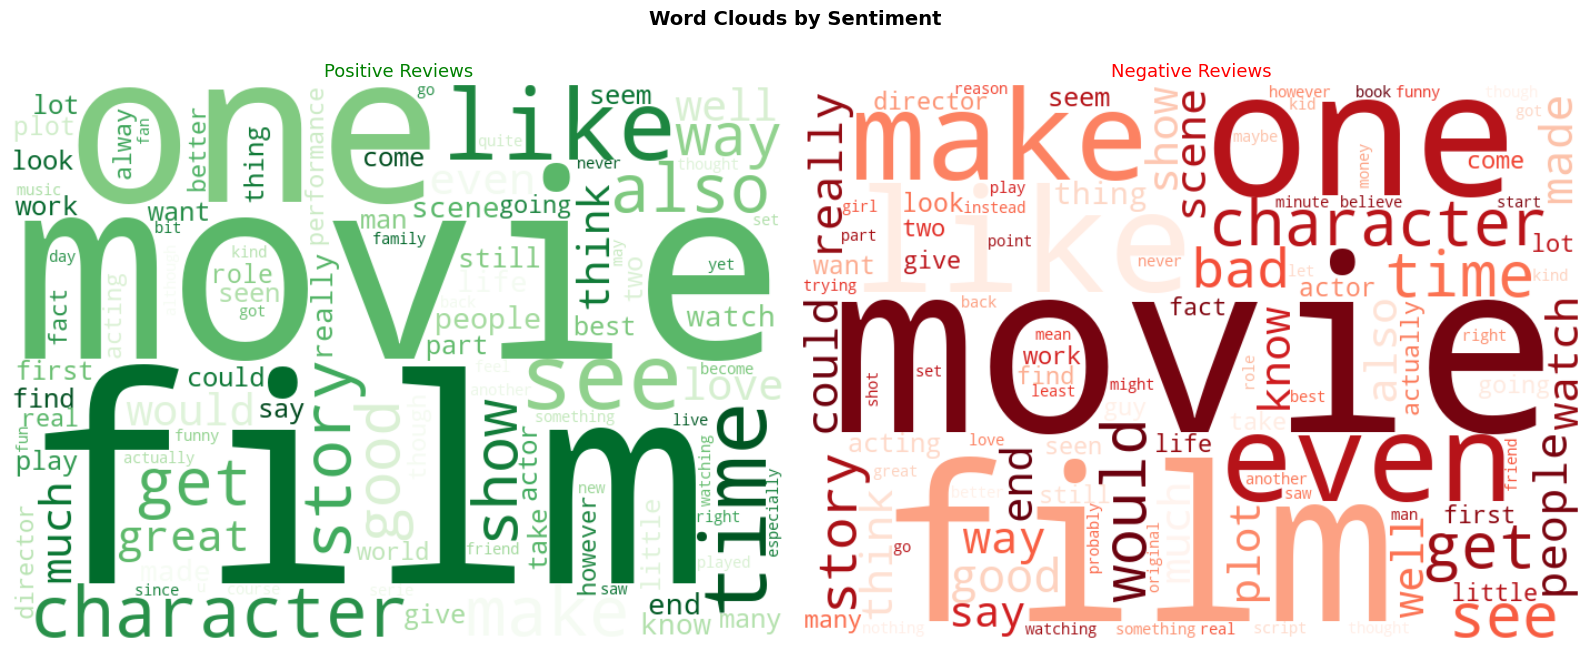

In [7]:
def clean_for_cloud(text):
    text = re.sub(r'<.*?>', ' ', text)       # remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', ' ', text) # keep letters only
    return text.lower()

stop_words = set(stopwords.words('english'))

pos_text = ' '.join(df[df['sentiment']=='positive']['review'].apply(clean_for_cloud))
neg_text = ' '.join(df[df['sentiment']=='negative']['review'].apply(clean_for_cloud))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Word Clouds by Sentiment', fontsize=14, fontweight='bold')

wc_pos = WordCloud(width=700, height=500, background_color='white',
                   colormap='Greens', stopwords=stop_words,
                   max_words=100).generate(pos_text)
wc_neg = WordCloud(width=700, height=500, background_color='white',
                   colormap='Reds', stopwords=stop_words,
                   max_words=100).generate(neg_text)

axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('Positive Reviews', fontsize=13, color='green')
axes[0].axis('off')

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('Negative Reviews', fontsize=13, color='red')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('plot_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.6 Top N-grams Analysis

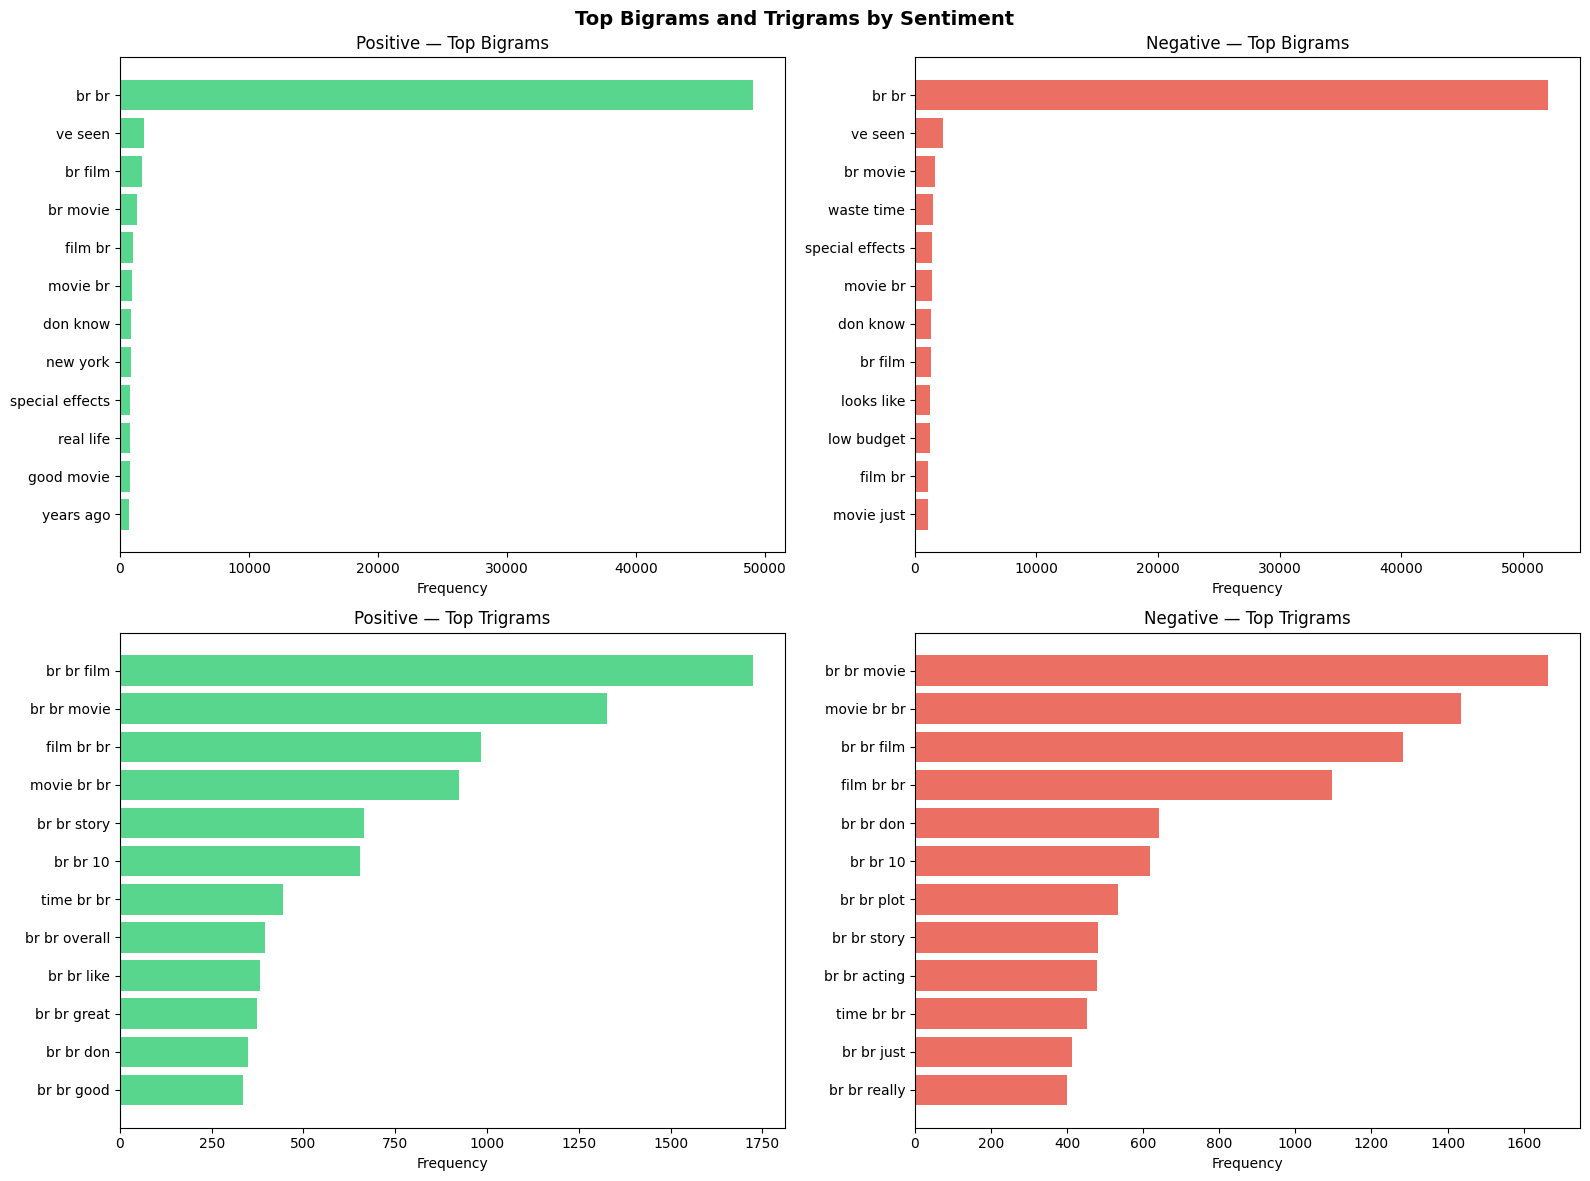

In [8]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n=2, top_k=15):
    vec = CountVectorizer(ngram_range=(n,n), stop_words='english', max_features=5000)
    bow = vec.fit_transform(corpus)
    freqs = zip(vec.get_feature_names_out(), bow.sum(axis=0).tolist()[0])
    return sorted(freqs, key=lambda x: x[1], reverse=True)[:top_k]

pos_reviews = df[df['sentiment']=='positive']['review']
neg_reviews = df[df['sentiment']=='negative']['review']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Top Bigrams and Trigrams by Sentiment', fontsize=14, fontweight='bold')

for i, (reviews, label, colour) in enumerate([
    (pos_reviews, 'Positive', '#2ECC71'),
    (neg_reviews, 'Negative', '#E74C3C')
]):
    for j, n in enumerate([2, 3]):
        ngrams = get_top_ngrams(reviews, n=n, top_k=12)
        words, counts = zip(*ngrams)
        axes[j,i].barh(list(reversed(words)), list(reversed(counts)),
                        color=colour, alpha=0.8)
        axes[j,i].set_title(f'{label} — Top {"Bigrams" if n==2 else "Trigrams"}')
        axes[j,i].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('plot_ngrams.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Data Preprocessing

In [9]:
stemmer    = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    """Full preprocessing pipeline:
       HTML removal → lowercase → punctuation removal →
       tokenise → stopword removal → stemming
    """
    text = re.sub(r'<.*?>',       ' ', text)   # remove HTML tags
    text = re.sub(r'&[a-z]+;',    ' ', text)   # remove HTML entities
    text = text.lower()
    text = re.sub(r'[^a-z\s]',   ' ', text)   # keep letters only
    text = re.sub(r'\s+',         ' ', text).strip()
    tokens = text.split()
    tokens = [stemmer.stem(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

print('Preprocessing reviews… (this may take ~30 seconds)')
df['clean_review'] = df['review'].apply(preprocess)

print('\nSample — Before preprocessing:')
print(df['review'].iloc[0][:200])
print('\nSample — After preprocessing:')
print(df['clean_review'].iloc[0][:200])

Preprocessing reviews… (this may take ~30 seconds)

Sample — Before preprocessing:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo

Sample — After preprocessing:
one review mention watch episod hook right exactli happen first thing struck brutal unflinch scene violenc set right word trust show faint heart timid show pull punch regard drug sex violenc hardcor c


In [10]:
# Encode labels: positive=1, negative=0
df['label'] = (df['sentiment'] == 'positive').astype(int)

# Train / Test split — 80/20 stratified
X = df['clean_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set : {len(X_train):,} samples')
print(f'Test set     : {len(X_test):,} samples')
print(f'Train positive: {y_train.sum():,}  |  Train negative: {(y_train==0).sum():,}')

Training set : 40,000 samples
Test set     : 10,000 samples
Train positive: 20,000  |  Train negative: 20,000


---
## 4. Text Vectorisation — TF-IDF

In [11]:
# TF-IDF Vectoriser with unigrams + bigrams
tfidf = TfidfVectorizer(
    max_features = 50_000,
    ngram_range  = (1, 2),
    sublinear_tf = True,    # apply log normalization
    min_df       = 3,       # ignore very rare terms
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'TF-IDF matrix shape  (train) : {X_train_tfidf.shape}')
print(f'TF-IDF matrix shape  (test)  : {X_test_tfidf.shape}')
print(f'Vocabulary size              : {len(tfidf.vocabulary_):,}')

TF-IDF matrix shape  (train) : (40000, 50000)
TF-IDF matrix shape  (test)  : (10000, 50000)
Vocabulary size              : 50,000


---
## 5. Supervised Text Classification Models
### 5.1 Model 1 — Logistic Regression

In [12]:
# Train Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
lr.fit(X_train_tfidf, y_train)

# Evaluate
y_pred_lr  = lr.predict(X_test_tfidf)
y_prob_lr  = lr.predict_proba(X_test_tfidf)[:,1]
acc_lr     = accuracy_score(y_test, y_pred_lr)
roc_lr     = roc_auc_score(y_test, y_prob_lr)

print('=' * 50)
print('MODEL 1: Logistic Regression')
print('=' * 50)
print(f'Accuracy : {acc_lr:.4f}  ({acc_lr*100:.2f}%)')
print(f'ROC-AUC  : {roc_lr:.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['Negative','Positive']))

MODEL 1: Logistic Regression
Accuracy : 0.9013  (90.13%)
ROC-AUC  : 0.9647

              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      5000
    Positive       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



### 5.2 Model 2 — Multinomial Naive Bayes

In [13]:
# Train Multinomial Naive Bayes
nb = MultinomialNB(alpha=1.0)
nb.fit(X_train_tfidf, y_train)

y_pred_nb  = nb.predict(X_test_tfidf)
y_prob_nb  = nb.predict_proba(X_test_tfidf)[:,1]
acc_nb     = accuracy_score(y_test, y_pred_nb)
roc_nb     = roc_auc_score(y_test, y_prob_nb)

print('=' * 50)
print('MODEL 2: Multinomial Naive Bayes')
print('=' * 50)
print(f'Accuracy : {acc_nb:.4f}  ({acc_nb*100:.2f}%)')
print(f'ROC-AUC  : {roc_nb:.4f}')
print()
print(classification_report(y_test, y_pred_nb, target_names=['Negative','Positive']))

MODEL 2: Multinomial Naive Bayes
Accuracy : 0.8801  (88.01%)
ROC-AUC  : 0.9496

              precision    recall  f1-score   support

    Negative       0.89      0.87      0.88      5000
    Positive       0.87      0.89      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



### 5.3 Model 3 — Linear SVM

In [14]:
# Train Linear SVM
svm = LinearSVC(random_state=42, max_iter=2000)
svm.fit(X_train_tfidf, y_train)

y_pred_svm = svm.predict(X_test_tfidf)
acc_svm    = accuracy_score(y_test, y_pred_svm)

print('=' * 50)
print('MODEL 3: Linear SVM')
print('=' * 50)
print(f'Accuracy : {acc_svm:.4f}  ({acc_svm*100:.2f}%)')
print()
print(classification_report(y_test, y_pred_svm, target_names=['Negative','Positive']))

MODEL 3: Linear SVM
Accuracy : 0.9056  (90.56%)

              precision    recall  f1-score   support

    Negative       0.91      0.90      0.91      5000
    Positive       0.90      0.91      0.91      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



### 5.4 Confusion Matrices

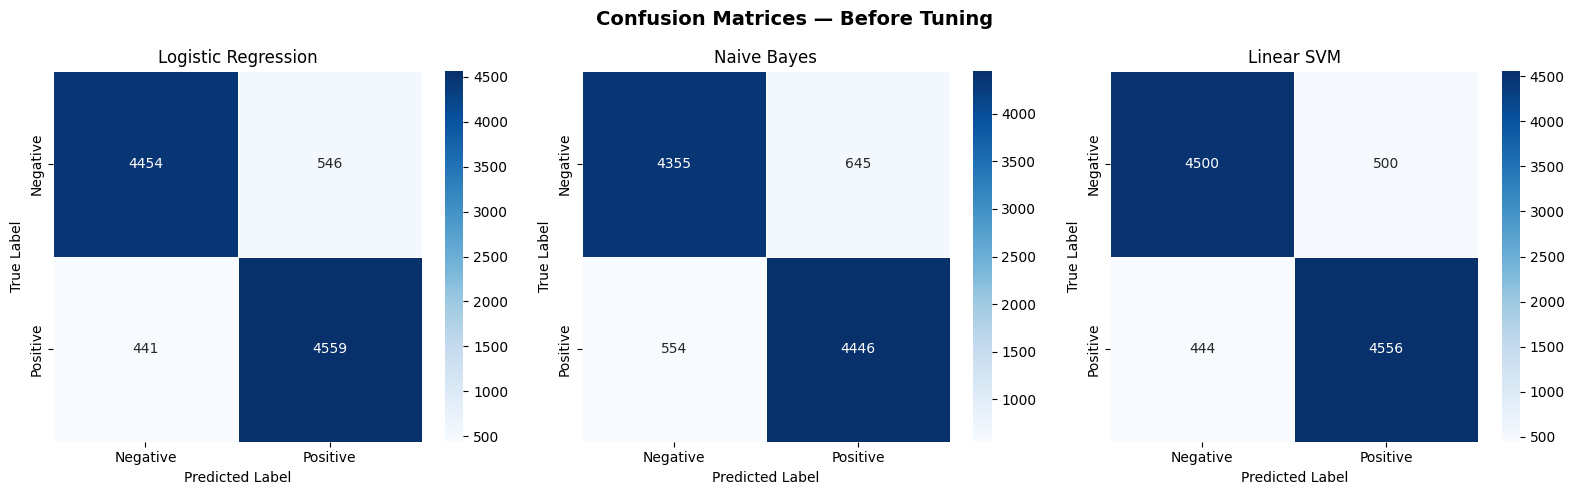

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confusion Matrices — Before Tuning', fontsize=14, fontweight='bold')

models = [
    (y_pred_lr,  'Logistic Regression'),
    (y_pred_nb,  'Naive Bayes'),
    (y_pred_svm, 'Linear SVM'),
]

for ax, (y_pred, name) in zip(axes, models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Negative','Positive'],
                yticklabels=['Negative','Positive'],
                linewidths=0.5)
    ax.set_title(name)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('plot_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.5 ROC Curves

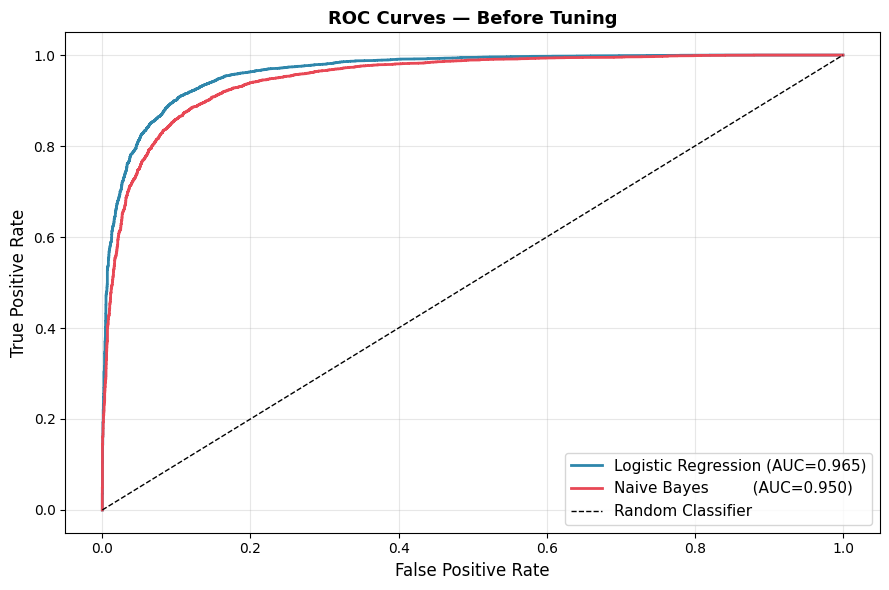

In [16]:
plt.figure(figsize=(9, 6))

for y_prob, label, colour in [
    (y_prob_lr, f'Logistic Regression (AUC={roc_lr:.3f})', '#2E86AB'),
    (y_prob_nb, f'Naive Bayes         (AUC={roc_nb:.3f})', '#E84855'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=label, linewidth=2, color=colour)

plt.plot([0,1],[0,1],'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Before Tuning', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plot_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Hyperparameter Tuning and Evaluation
### 6.1 Tune Logistic Regression — Grid Search

In [17]:
# Grid Search for Logistic Regression
lr_params = {
    'C'      : [0.01, 0.1, 1, 10, 100],
    'solver' : ['lbfgs', 'liblinear'],
    'max_iter': [500, 1000],
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_params,
    cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
lr_grid.fit(X_train_tfidf, y_train)

print(f'Best Parameters : {lr_grid.best_params_}')
print(f'Best CV Score   : {lr_grid.best_score_:.4f}')

# Evaluate tuned model
lr_best       = lr_grid.best_estimator_
y_pred_lr_t   = lr_best.predict(X_test_tfidf)
y_prob_lr_t   = lr_best.predict_proba(X_test_tfidf)[:,1]
acc_lr_tuned  = accuracy_score(y_test, y_pred_lr_t)
roc_lr_tuned  = roc_auc_score(y_test, y_prob_lr_t)

print(f'\nTuned Accuracy : {acc_lr_tuned:.4f}  ({acc_lr_tuned*100:.2f}%)')
print(f'Tuned ROC-AUC  : {roc_lr_tuned:.4f}')
print(classification_report(y_test, y_pred_lr_t, target_names=['Negative','Positive']))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters : {'C': 10, 'max_iter': 500, 'solver': 'lbfgs'}
Best CV Score   : 0.9022

Tuned Accuracy : 0.9049  (90.49%)
Tuned ROC-AUC  : 0.9661
              precision    recall  f1-score   support

    Negative       0.91      0.90      0.90      5000
    Positive       0.90      0.91      0.91      5000

    accuracy                           0.90     10000
   macro avg       0.91      0.90      0.90     10000
weighted avg       0.91      0.90      0.90     10000



### 6.2 Tune Naive Bayes — Grid Search

In [18]:
nb_params = {'alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0]}

nb_grid = GridSearchCV(
    MultinomialNB(),
    nb_params,
    cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
nb_grid.fit(X_train_tfidf, y_train)

print(f'Best Parameters : {nb_grid.best_params_}')
print(f'Best CV Score   : {nb_grid.best_score_:.4f}')

nb_best      = nb_grid.best_estimator_
y_pred_nb_t  = nb_best.predict(X_test_tfidf)
y_prob_nb_t  = nb_best.predict_proba(X_test_tfidf)[:,1]
acc_nb_tuned = accuracy_score(y_test, y_pred_nb_t)
roc_nb_tuned = roc_auc_score(y_test, y_prob_nb_t)

print(f'\nTuned Accuracy : {acc_nb_tuned:.4f}  ({acc_nb_tuned*100:.2f}%)')
print(f'Tuned ROC-AUC  : {roc_nb_tuned:.4f}')
print(classification_report(y_test, y_pred_nb_t, target_names=['Negative','Positive']))

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best Parameters : {'alpha': 0.1}
Best CV Score   : 0.8809

Tuned Accuracy : 0.8808  (88.08%)
Tuned ROC-AUC  : 0.9499
              precision    recall  f1-score   support

    Negative       0.89      0.87      0.88      5000
    Positive       0.88      0.89      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



### 6.3 Tune Linear SVM — Random Search

In [19]:
from scipy.stats import uniform

svm_params = {
    'C'   : uniform(loc=0.01, scale=10),
    'loss': ['hinge', 'squared_hinge'],
}

svm_rand = RandomizedSearchCV(
    LinearSVC(random_state=42, max_iter=3000),
    svm_params,
    n_iter=20, cv=5, scoring='accuracy',
    n_jobs=-1, random_state=42, verbose=1
)
svm_rand.fit(X_train_tfidf, y_train)

print(f'Best Parameters : {svm_rand.best_params_}')
print(f'Best CV Score   : {svm_rand.best_score_:.4f}')

svm_best       = svm_rand.best_estimator_
y_pred_svm_t   = svm_best.predict(X_test_tfidf)
acc_svm_tuned  = accuracy_score(y_test, y_pred_svm_t)

print(f'\nTuned Accuracy : {acc_svm_tuned:.4f}  ({acc_svm_tuned*100:.2f}%)')
print(classification_report(y_test, y_pred_svm_t, target_names=['Negative','Positive']))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters : {'C': np.float64(0.5741157902710026), 'loss': 'squared_hinge'}
Best CV Score   : 0.9020

Tuned Accuracy : 0.9076  (90.76%)
              precision    recall  f1-score   support

    Negative       0.91      0.90      0.91      5000
    Positive       0.90      0.92      0.91      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



### 6.4 Model Comparison — Before vs After Tuning

In [20]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'Linear SVM'],
    'Before Tuning (%)': [acc_lr*100, acc_nb*100, acc_svm*100],
    'After Tuning (%)' : [acc_lr_tuned*100, acc_nb_tuned*100, acc_svm_tuned*100],
})
results['Improvement (%)'] = results['After Tuning (%)'] - results['Before Tuning (%)']
print(results.round(3).to_string(index=False))

              Model  Before Tuning (%)  After Tuning (%)  Improvement (%)
Logistic Regression              90.13             90.49             0.36
        Naive Bayes              88.01             88.08             0.07
         Linear SVM              90.56             90.76             0.20


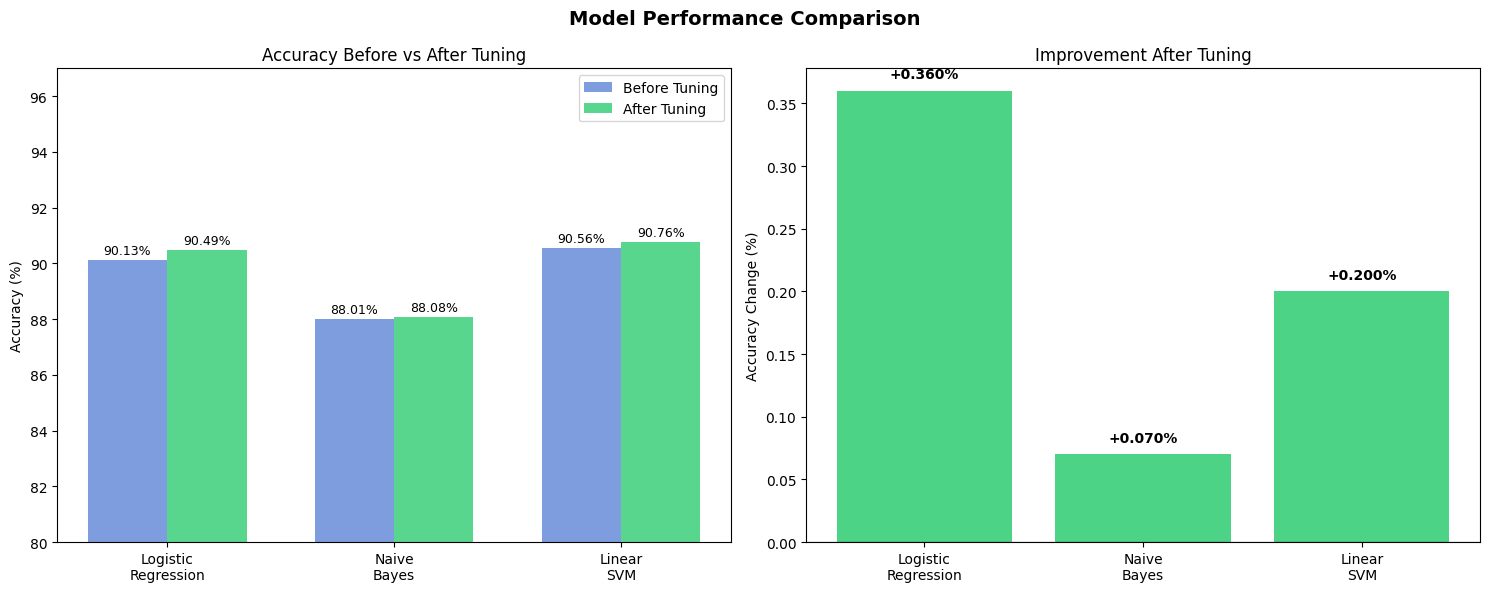

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')

models_labels = ['Logistic\nRegression', 'Naive\nBayes', 'Linear\nSVM']
before = [acc_lr*100,       acc_nb*100,       acc_svm*100]
after  = [acc_lr_tuned*100, acc_nb_tuned*100, acc_svm_tuned*100]
x = np.arange(len(models_labels))
w = 0.35

# Bar comparison
bars1 = axes[0].bar(x - w/2, before, w, label='Before Tuning', color='#5C85D6', alpha=0.8)
bars2 = axes[0].bar(x + w/2, after,  w, label='After Tuning',  color='#2ECC71', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_labels)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(80, 97)
axes[0].set_title('Accuracy Before vs After Tuning')
axes[0].legend()
for bar in bars1:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=9)

# Improvement chart
improvements = [a-b for a,b in zip(after, before)]
colours = ['#2ECC71' if i > 0 else '#E74C3C' for i in improvements]
axes[1].bar(models_labels, improvements, color=colours, alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('Accuracy Change (%)')
axes[1].set_title('Improvement After Tuning')
for i, (m, v) in enumerate(zip(models_labels, improvements)):
    axes[1].text(i, v + 0.01, f'+{v:.3f}%' if v>=0 else f'{v:.3f}%',
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('plot_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.5 Select Best Model

In [22]:
final_results = {
    'Logistic Regression': acc_lr_tuned,
    'Naive Bayes'        : acc_nb_tuned,
    'Linear SVM'         : acc_svm_tuned,
}

best_model_name = max(final_results, key=final_results.get)
best_acc        = final_results[best_model_name]

print('='*50)
print('FINAL MODEL RESULTS')
print('='*50)
for name, acc in final_results.items():
    star = ' ← BEST' if name == best_model_name else ''
    print(f'  {name:<25} {acc*100:.2f}%{star}')

print(f'\nBest Model: {best_model_name} with {best_acc*100:.2f}% accuracy')

FINAL MODEL RESULTS
  Logistic Regression       90.49%
  Naive Bayes               88.08%
  Linear SVM                90.76% ← BEST

Best Model: Linear SVM with 90.76% accuracy


---
## 7. Save Best Model for Deployment

In [23]:
# Save the best model + vectoriser
best_models = {
    'Logistic Regression': lr_best,
    'Naive Bayes'        : nb_best,
    'Linear SVM'         : svm_best,
}

best_clf = best_models[best_model_name]

with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_clf, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print(f'Saved: best_model.pkl       ({best_model_name})')
print(f'Saved: tfidf_vectorizer.pkl')
print('\nReady for deployment! ✔')

Saved: best_model.pkl       (Linear SVM)
Saved: tfidf_vectorizer.pkl

Ready for deployment! ✔


---
## 8. Cross-Validation Summary

In [24]:
print('5-Fold Cross-Validation Scores (tuned models):')
print('-'*50)

for name, clf in [('Logistic Regression', lr_best),
                   ('Naive Bayes',         nb_best),
                   ('Linear SVM',          svm_best)]:
    scores = cross_val_score(clf, X_train_tfidf, y_train, cv=5, scoring='accuracy')
    print(f'{name:<25} Mean={scores.mean():.4f}  Std={scores.std():.4f}')

5-Fold Cross-Validation Scores (tuned models):
--------------------------------------------------
Logistic Regression       Mean=0.9022  Std=0.0039
Naive Bayes               Mean=0.8809  Std=0.0025
Linear SVM                Mean=0.9020  Std=0.0026
